In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.style.use('default')

In [149]:
df=pd.read_csv(r"D:\Data-Science\DATA Cleaning\Netflix Eda\Data\netflix_titles.csv")

In [150]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
df['country'].fillna('Unknown',inplace=)

In [ ]:
df['director'].fillna('Not given',inplace=)


In [153]:
df['duration'].isnull().sum()

np.int64(3)

In [154]:
df['Season']=df['show_id'].str.extract('(\d+)').astype(int)

In [ ]:
df.drop('show_',inplace=True,axis=1)

In [157]:
df['duration']=df['duration'].fillna(0)

In [158]:
df['minutes']=np.where(
    df['duration'].str.contains('min',na=False),
    df['duration'].str.extract(r'(\d+)').iloc[:,0].astype(float),
    df['duration'].str.extract(r'(\d+)').iloc[:,0].astype(float)*450
)

Text(0, 0.5, 'Count')

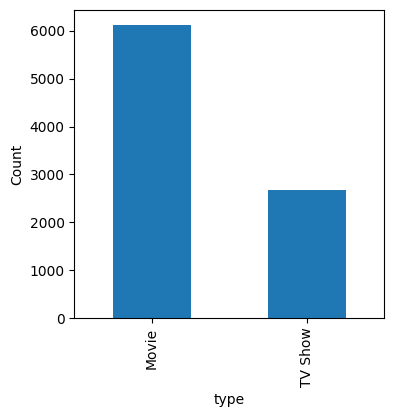

In [159]:
plt.figure(figsize=(4,4))
df['type'].value_counts().plot(kind='bar')
plt.ylabel('Count')

# Netflix has more movies than than tv shows 

<Axes: ylabel='count'>

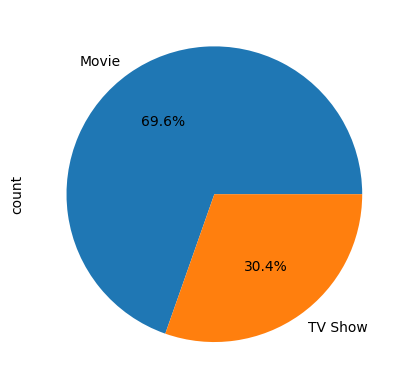

In [169]:
df['type'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: xlabel='release_year'>

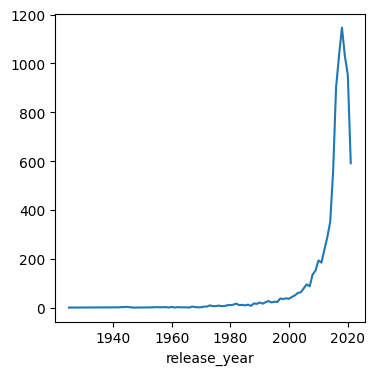

In [171]:
plt.figure(figsize=(4,4))
df.groupby('release_year').size().plot(kind='line')

# Content releases increased significantly after 2015.

<Axes: ylabel='listed_in'>

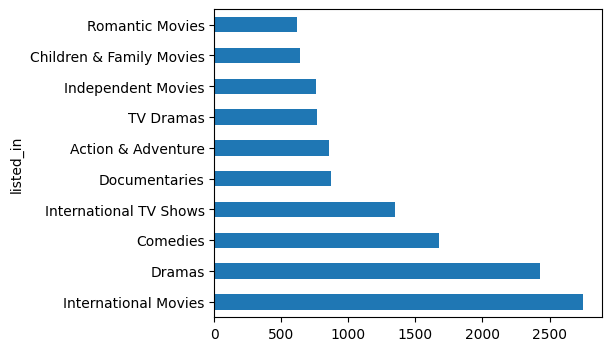

In [161]:
plt.figure(figsize=(5,4))
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='barh')

# Drama dominates Netflix’s content library

In [ ]:
sns.histplot(df['duration_numaric'],bins=20)

#  Most movies are between 50 min to 150 min

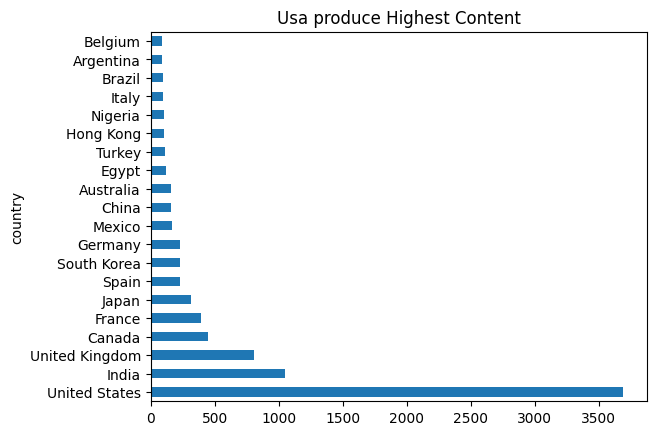

In [163]:

df['country'].str.split(', ').explode().value_counts().head(20).plot(kind='barh')
plt.title('Usa produce Highest Content')
plt.show()

In [164]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Text(0, 0.5, 'Count')

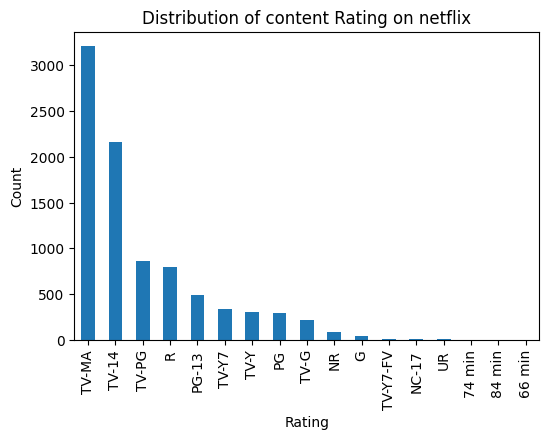

In [165]:
plt.figure(figsize=(6,4))
df['rating'].value_counts().plot(kind='bar')
plt.title('Distribution of content Rating on netflix')
plt.xlabel('Rating')
plt.ylabel('Count')

# TV-MA content dominates the platform, indicating Netflix’s strong focus on mature audiences.

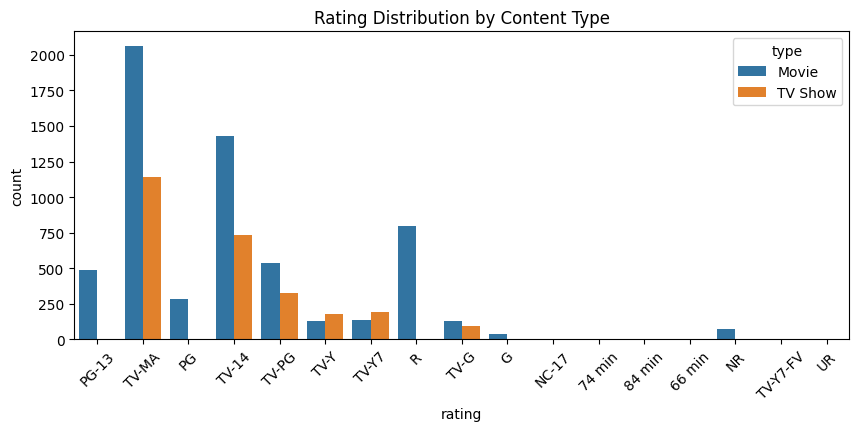

In [166]:
plt.figure(figsize=(10,4))
sns.countplot(x='rating',hue='type',data=df)
plt.title('Rating Distribution by Content Type')
plt.xticks(rotation=45)
plt.show()